# Overriding a Mechanism in MusicBox

Each MusicBox instance can only work with one mechanism at a time. To change the chemical system, you can load a new mechanism using the `load_mechanism()` method, which will replace the existing one. This tutorial demonstrates how to switch from one mechanism to a completely different chemical system.

## 1. Creating the Mechanism and Box Model

This is simply a copy of the first half of the Basic Workflow Tutorial to set up the mechanism for overriding.

In [1]:
from acom_music_box import MusicBox
import musica.mechanism_configuration as mc
import matplotlib.pyplot as plt

# Create species and phase for the reactions
X = mc.Species(name="X")
Y = mc.Species(name="Y")
Z = mc.Species(name="Z")
species = {"X": X, "Y": Y, "Z": Z}
gas = mc.Phase(name="gas", species=list(species.values()))

# Create the Arrhenius reactions
reaction1 = mc.Arrhenius(name="X->Y", A=4.0e-3, C=50, reactants=[species["X"]], products=[species["Y"]], gas_phase=gas)
reaction2 = mc.Arrhenius(name="Y->Z", A=4.0e-3, C=50, reactants=[species["Y"]], products=[species["Z"]], gas_phase=gas)
rxns = {"X->Y": reaction1, "Y->Z": reaction2}

# Create the mechanism that is defined by the species, phases, and reactions
mechanism = mc.Mechanism(
    name="tutorial_mechanism", 
    species=list(species.values()), 
    phases=[gas], 
    reactions=list(rxns.values()))

# Create the box model that contains the mechanism
box_model = MusicBox()
box_model.load_mechanism(mechanism)

## 2. Overriding with a New Mechanism

Now we'll completely replace the mechanism with a different chemical reactions. Instead of the Arrhenius reactions system, we'll create quantum tunneling reactions.

This demonstrates how to override a mechanism by:
- Using different species (G and H instead of X, Y, Z)
- Using quantum tunneling reactions

Here's the code to define and load the new mechanism:

In [2]:
# Create new species and phase
G = mc.Species(name="G")
H = mc.Species(name="H")
species = {"G": G, "H": H}

gas = mc.Phase(name="gas", species=list(species.values()))

# Create the reactions and overwrite the variables
reaction1 = mc.Tunneling(name="G->H", A=2.0e-3, B=2, C=50, reactants=[species["G"]], products=[species["H"]], gas_phase=gas)
reaction2 = mc.Tunneling(name="H->G", A=9.0e-3, B=2, C=50, reactants=[species["H"]], products=[species["G"]], gas_phase=gas)
rxns = {"G->H": reaction1, "H->G": reaction2}


# Create the new mechanism with the newly defiend reactions
mechanism = mc.Mechanism(
    name="new_mechanism", 
    species=list(species.values()), 
    phases=[gas], 
    reactions=list(rxns.values())
)

# Override the previous mechanism by loading the new one
box_model.load_mechanism(mechanism)

## 3. Running and Visualizing the New Box Model

Now we can run the simulation with our new reversible mechanism. Notice that we're using the species names "G" and "H" instead of "X", "Y", and "Z" from the previous mechanism.

The rest of this code is adapted from the Basic Workflow Tutorial. For detailed explanations of each step, refer to that tutorial:

,time.s,ENV.temperature.K,ENV.pressure.Pa,ENV.air number density.mol m-3,CONC.G.mol m-3,CONC.H.mol m-3
0,0.0,298.15,101325.0,40.874045,2.500000,5.000000
1,20.0,298.15,101325.0,40.874045,3.213819,4.286181
2,40.0,298.15,101325.0,40.874045,3.787516,3.712484
3,60.0,298.15,101325.0,40.874045,4.248595,3.251405
4,80.0,298.15,101325.0,40.874045,4.619165,2.880835
5,100.0,298.15,101325.0,40.874045,4.916991,2.583009
6,120.0,310.00,100100.0,38.836331,5.156409,2.343591
7,140.0,310.00,100100.0,38.836331,5.348819,2.151181
8,160.0,310.00,100100.0,38.836331,5.503449,1.996551
9,180.0,310.00,100100.0,38.836331,5.627719,1.872281


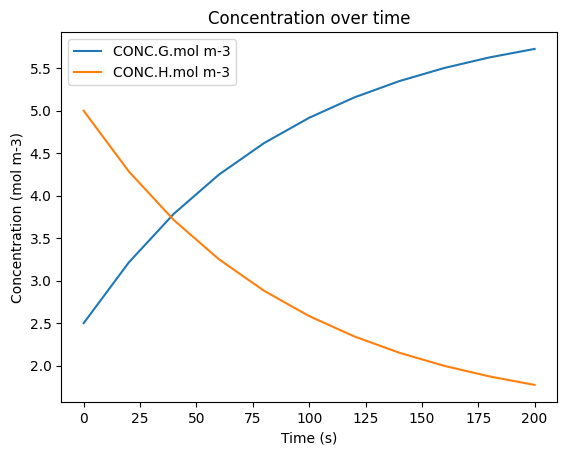

In [3]:
# Set the conditions of the box model at time = 0 s
box_model.set_condition(
    time=0,
    temperature=298.15,  # Units: Kelvin (K)
    pressure=101325.0,   # Units: Pascals (Pa)
    concentrations={     # Units: mol/m^3
        "G": 2.5,
        "H": 5.0,
    }
)

# Set the box model conditions at the defined time
box_model.set_condition(
    time=100.0,         # Units: Seconds (s)
    temperature=310.0,  # Units: Kelvin (K)
    pressure=100100.0   # Units: Pascals (Pa)
)

# Set the additional configuration options for the box model
box_model.box_model_options.simulation_length = 200  # Units: Seconds (s)
box_model.box_model_options.chem_step_time = 1       # Units: Seconds (s)
box_model.box_model_options.output_step_time = 20    # Units: Seconds (s)

df = box_model.solve()
display(df)
df.plot(x='time.s', y=['CONC.G.mol m-3', 'CONC.H.mol m-3'], title='Concentration over time', ylabel='Concentration (mol m-3)', xlabel='Time (s)')
plt.show()